<a href="https://colab.research.google.com/github/Ikram0-4/Campagne_Annotation_Presupp/blob/main/cluster_aircall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas gspread

In [ ]:
!pip install google-auth
!pip install spacy
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 65.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import gspread
from google.colab import auth
import google.auth
import re
from collections import Counter
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

In [ ]:
auth.authenticate_user()

In [ ]:
creds, _ = google.auth.default()
google_client = gspread.authorize(creds)

In [ ]:
spreadsheet_id = "1R87OJRWlvRnWhYmAHLmd5nZw_jtKijrsW9x0dfosJVA"
spreadsheet = google_client.open_by_key(spreadsheet_id)
print(f"Successfully opened spreadsheet: {spreadsheet.title}")

Successfully opened spreadsheet: ☎️ AIRCALL - BackUp - Transcription Inbound & Outbond (Sales, SDR, Care)


In [ ]:
gsheet1 = spreadsheet.get_worksheet(1)
gsheet2 = spreadsheet.get_worksheet(2)
gsheet3 = spreadsheet.get_worksheet(3)

In [ ]:
print(gsheet1.title)
print(gsheet2.title)
print(gsheet3.title)

1. SDR ENTRANT WEB - filter
1. SDR MOBILE - filter
2. TEAM CARE - filter


In [ ]:
df  = pd.DataFrame(gsheet1.get_all_records())
df1 = pd.DataFrame(gsheet2.get_all_records())
df2 = pd.DataFrame(gsheet3.get_all_records())
df  = pd.concat([df, df1], ignore_index=True)
df.columns  = df.columns.str.strip()
df2.columns = df2.columns.str.strip()

# --- Nettoyage tags ---
df["Aircall Tag"]  = df["Aircall Tag"].astype(str).str.lower().str.strip()
df2["Aircall Tag"] = df2["Aircall Tag"].astype(str).str.lower().str.strip()
bad_tags = ["sales - no answer/prospection", "voicemail drop", "voicemail",
            "empty", "ai voicemail", "no answer", ""]
df = df[~df["Aircall Tag"].isin(bad_tags)].copy()
df = df[~df["Aircall Tag"].str.contains("no answer|voicemail|drop|empty", na=False)].copy()
df2 = df2[df2["Aircall Tag"].str.contains("care", na=False)].copy()

print("df  (Sales):", len(df), "lignes")
print("df2 (Care) :", len(df2), "lignes")

PROSPECT_PATTERN = re.compile(
    r'(?:Prospect|Extern User)\s*:\s*(.*?)(?=Foodles User\s*:|Prospect\s*:|Extern User\s*:|$)',
    re.DOTALL
)

def clean_segment(s):
    s = s.replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def extract_speaker(text):
    if not isinstance(text, str):
        return ""
    parts = PROSPECT_PATTERN.findall(text)
    parts = [clean_segment(p) for p in parts]
    return " ".join([p for p in parts if len(p) > 2])

df["prospect_text"]  = df["Call Transcription"].fillna("").apply(extract_speaker)
df2["prospect_text"] = df2["Call Transcription"].fillna("").apply(extract_speaker)

df  = df[df["prospect_text"].str.len()   > 15].copy()
df2 = df2[df2["prospect_text"].str.len() > 15].copy()

print("Après extraction — Sales:", len(df), "| Care:", len(df2))

# --- Lemmatisation ---
nlp = spacy.load("fr_core_news_sm")

CUSTOM_STOPWORDS = set([
    "bonjour", "bonsoir", "salut", "oui", "non", "ok",
    "merci", "accord", "bye", "bon", "revoir", "allô", "-ce", "-là", "numéro",
    "aujourd'hui", "cas", "bien", "être", "journée", "avoir", "voir", "vouloir",
    "pouvoir", "falloir", "dire", "remercier", "venir", "donner", "répondre",
    "du coup", "le coup", "coup", "faire", "parfaire", "beaucoup", "heure",
    "euh", "hein", "ah", "oh", "hm", "ouais", "ouai", "appel", "appeler",
    "téléphone", "mail", "message", "rappeler", "contacter", "messagerie",
    "vocal", "monsieur", "madame",
])

def lemmatize(texts):
    cleaned = []
    for doc in nlp.pipe(texts, batch_size=50):
        tokens = []
        for token in doc:
            lemma = token.lemma_.lower().strip()
            text  = token.text.lower().strip()
            if (
                not token.is_stop and not token.is_punct
                and not token.is_space and not token.like_num
                and len(lemma) > 2
                and lemma not in CUSTOM_STOPWORDS
                and text  not in CUSTOM_STOPWORDS
            ):
                tokens.append(lemma)
        cleaned.append(" ".join(tokens))
    return cleaned

print("Lemmatisation Sales...")
df["prospect_clean"]  = lemmatize(df["prospect_text"].tolist())
print("Lemmatisation Care...")
df2["prospect_clean"] = lemmatize(df2["prospect_text"].tolist())

# --- Post-filtre stopwords ---
for frame in [df, df2]:
    frame["prospect_clean"] = frame["prospect_clean"].apply(
        lambda x: " ".join([w for w in x.lower().split()
                             if w not in CUSTOM_STOPWORDS and len(w) > 2])
    )

# --- Stats comparées ---
words_sales = " ".join(df["prospect_clean"].tolist()).split()
words_care  = " ".join(df2["prospect_clean"].tolist()).split()

top50_sales = Counter(words_sales).most_common(50)
top50_care  = Counter(words_care).most_common(50)

print("\n" + "=" * 60)
print("COMPARAISON SALES vs CARE — TOP 50")
print("=" * 60)
print(f"{'#':<4} {'SALES':<25} {'N':<8} {'CARE':<25} {'N'}")
print("-" * 70)
for i, ((ws, cs), (wc, cc)) in enumerate(zip(top50_sales, top50_care), 1):
    print(f"{i:<4} {ws:<25} {cs:<8} {wc:<25} {cc}")

# --- Mots exclusifs à chaque côté ---
set_sales = set([w for w, _ in top50_sales])
set_care  = set([w for w, _ in top50_care])

print("\nMots TOP50 Sales absents du TOP50 Care :", set_sales - set_care)
print("Mots TOP50 Care absents du TOP50 Sales :", set_care - set_sales)

df  (Sales): 383 lignes
df2 (Care) : 648 lignes
Après extraction — Sales: 376 | Care: 636
Lemmatisation Sales...
Lemmatisation Care...

COMPARAISON SALES vs CARE — TOP 50
#    SALES                     N        CARE                      N
----------------------------------------------------------------------
1    savoir                    202      frigo                     544
2    frigo                     122      prendre                   395
3    petit                     111      savoir                    353
4    site                      109      compte                    283
5    mettre                    103      euro                      266
6    chose                     102      carte                     255
7    souci                     101      problème                  206
8    entreprise                101      marche                    204
9    prendre                   96       passer                    187
10   service                   90       mettre              

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

corpus_sales = df["prospect_clean"].tolist()
corpus_care  = df2["prospect_clean"].tolist()
corpus_all   = corpus_sales + corpus_care

labels = ["sales"] * len(corpus_sales) + ["care"] * len(corpus_care)
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X = vectorizer.fit_transform(corpus_all)
terms = vectorizer.get_feature_names_out()
X_sales = X[:len(corpus_sales)]
X_care  = X[len(corpus_sales):]

scores_sales = X_sales.mean(axis=0).A1
scores_care  = X_care.mean(axis=0).A1

diff_sales = scores_sales - scores_care
diff_care  = scores_care  - scores_sales
top_sales_idx = np.argsort(diff_sales)[::-1][:30]
top_care_idx  = np.argsort(diff_care)[::-1][:30]

print("=" * 65)
print("CARACTÉRISTIQUES PROPRES — SALES vs CARE")
print("=" * 65)
print(f"{'#':<4} {'SALES UNIQUEMENT':<28} {'SCORE':<10} {'CARE UNIQUEMENT':<28} {'SCORE'}")
print("-" * 75)
for i, (si, ci) in enumerate(zip(top_sales_idx, top_care_idx), 1):
    print(f"{i:<4} {terms[si]:<28} {diff_sales[si]:<10.4f} {terms[ci]:<28} {diff_care[ci]:.4f}")

CARACTÉRISTIQUES PROPRES — SALES vs CARE
#    SALES UNIQUEMENT             SCORE      CARE UNIQUEMENT              SCORE
---------------------------------------------------------------------------
1    besoin                       0.0216     frigo                        0.0480
2    sujet                        0.0188     prendre                      0.0294
3    prie                         0.0175     carte                        0.0261
4    instant                      0.0163     compte                       0.0257
5    occuper                      0.0161     ouvrir                       0.0231
6    restauration                 0.0160     code                         0.0219
7    vraiment                     0.0159     euro                         0.0207
8    entreprise                   0.0150     marche                       0.0205
9    réunion                      0.0135     problème                     0.0176
10   restaurant                   0.0134     fonctionner                  

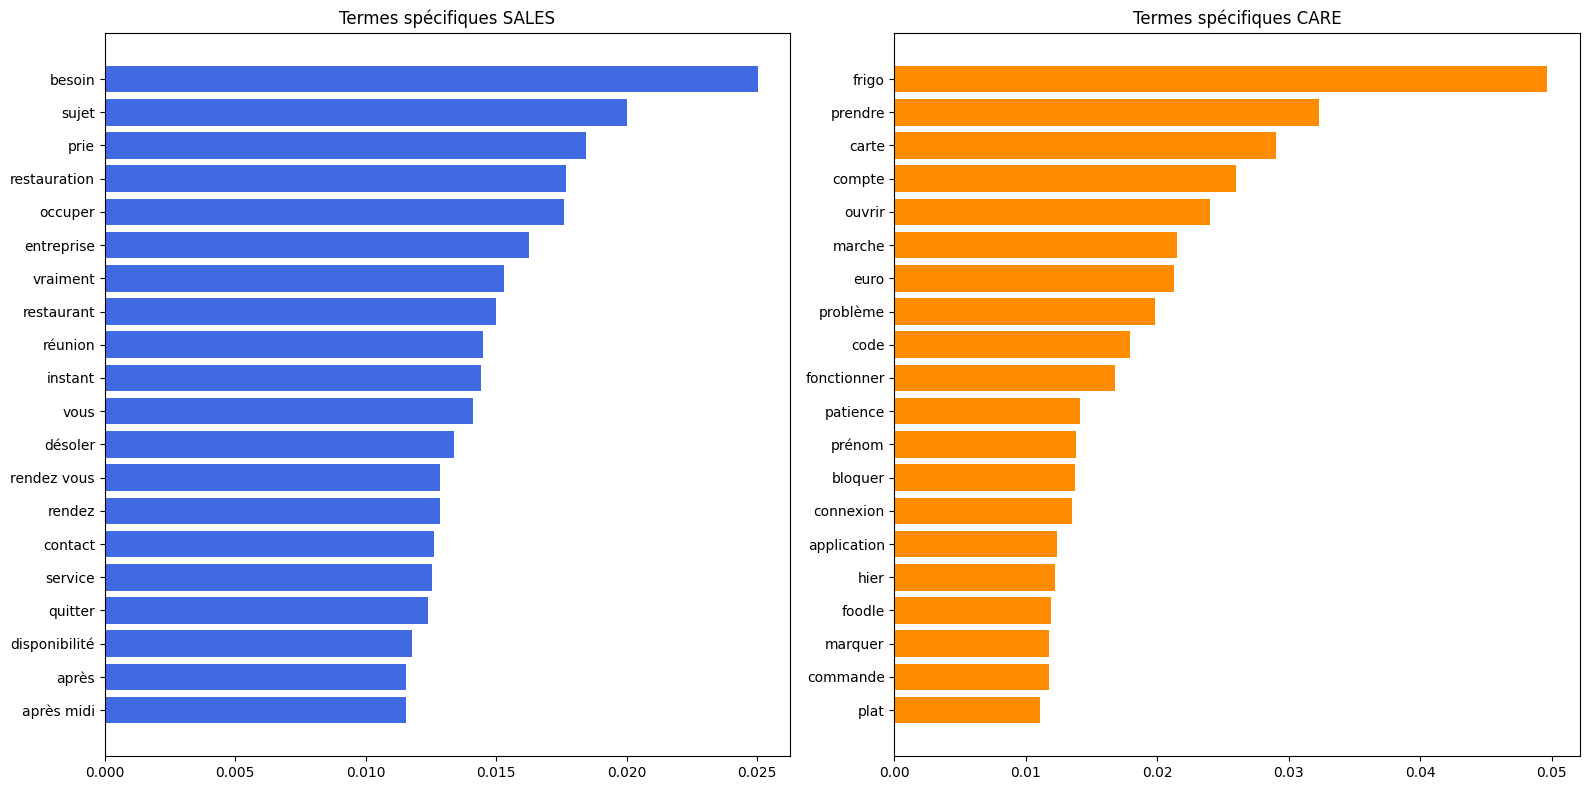

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

top_n = 20

sales_df = pd.DataFrame({
    "term": terms[top_sales_idx[:top_n]],
    "score": diff_sales[top_sales_idx[:top_n]]
})

care_df = pd.DataFrame({
    "term": terms[top_care_idx[:top_n]],
    "score": diff_care[top_care_idx[:top_n]]
})

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].barh(
    sales_df["term"][::-1],
    sales_df["score"][::-1],
    color="royalblue"
)
axes[0].set_title("Termes spécifiques SALES")

axes[1].barh(
    care_df["term"][::-1],
    care_df["score"][::-1],
    color="darkorange"
)
axes[1].set_title("Termes spécifiques CARE")

plt.tight_layout()
plt.show()

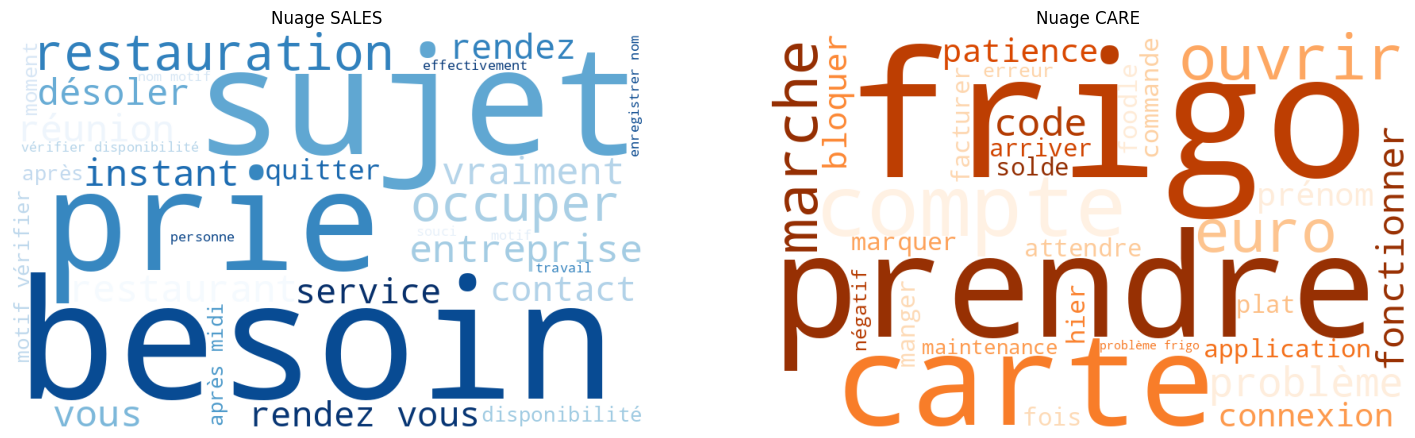

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sales_words = {
    terms[i]: diff_sales[i]
    for i in top_sales_idx[:100]
}

care_words = {
    terms[i]: diff_care[i]
    for i in top_care_idx[:100]
}

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

wc_sales = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="Blues"
).generate_from_frequencies(sales_words)

axes[0].imshow(wc_sales)
axes[0].axis("off")
axes[0].set_title("Nuage SALES")

wc_care = WordCloud(
    width=800,
    height=500,
    background_color="white",
    colormap="Oranges"
).generate_from_frequencies(care_words)

axes[1].imshow(wc_care)
axes[1].axis("off")
axes[1].set_title("Nuage CARE")

plt.show()

In [ ]:
import re
from IPython.display import HTML, display

PIVOT = "savoir"
WINDOW = 15

rows = []

for text in df2["prospect_text"].dropna():
    tokens = re.findall(r"\w+(?:[-']\w+)*|[^\w\s]", text)

    for i, token in enumerate(tokens):
        if token.lower() == PIVOT:
            left = " ".join(tokens[max(0, i-WINDOW):i])
            right = " ".join(tokens[i+1:i+WINDOW+1])
            rows.append({"gauche": left, "pivot": token, "droite": right})

kwic_savoir = pd.DataFrame(rows)
print(f"{len(kwic_savoir)} occurrences trouvées")

def render_kwic(df):
    html = """
    <style>
        .kwic-table { border-collapse: collapse; width: 100%; font-family: monospace; font-size: 13px; }
        .kwic-table td { padding: 6px 8px; vertical-align: middle; }
        .kwic-gauche { text-align: right; white-space: nowrap; overflow: hidden; max-width: 350px; color: #444; }
        .kwic-pivot { text-align: center; font-weight: bold; background: #ffe082; padding: 4px 10px; border-radius: 4px; color: #000; }
        .kwic-droite { text-align: left; white-space: nowrap; overflow: hidden; max-width: 350px; color: #444; }
        .kwic-table tr:nth-child(even) { background: #f7f7f7; }
        .kwic-table tr:hover { background: #eef; }
    </style>
    <table class="kwic-table">
    """
    for _, row in df.iterrows():
        html += f"""
        <tr>
            <td class="kwic-gauche">{row['gauche']}</td>
            <td class="kwic-pivot">{row['pivot']}</td>
            <td class="kwic-droite">{row['droite']}</td>
        </tr>
        """
    html += "</table>"
    display(HTML(html))

render_kwic(kwic_savoir.head(30))

91 occurrences trouvées


"Nesco à Colombes et on a eu un souci samedi les frigos , je voulais",savoir,"si vous étiez au courant . En fait , ne sont pas ouverts . Les"
"un message d'erreur et il n'est toujours pas parti . Du coup , je voulais",savoir,"où ça en était . Oui , je vous ai appelé il y a une"
"pour lui éviter de l'embêter avec la création de son compte Foodle , je voulais",savoir,si vous pouvez lui en créer un et je lui transmettrai ensuite son mot de
"appelle , je suis sur Blagnac de Richbourg à Blagnac en fait et je voudrais",savoir,en fait je me suis trompée de dessert et je ne sais pas comment je
a pas la notification de de d'où est l'erreur quoi en fait . Je voulais,savoir,"si c'était possible d'échanger ou pas . D'accord . Oui , bonato , B0NAT0 ."
que j'ai un solde dans le mauvais sens de 4 euros 19 . Je voudrais,savoir,"à quoi cela est dû . Et si c'est possible , alors de faire l'opération"
"aujourd'hui , mais demain , pour reprendre la ticket reste si c'est , j'aimerais d'abord",savoir,à quoi c'est dû et après comment on fait pour régulariser avec ma carte ticket
"elle me dit qu'elle n'est rattachée qu'à Paris étoiles . Je lui dis , j'aimerais",savoir,"si c'est possible de vérifier . Le nom de famille , c'est BUEING , Raina"
"services , mais ça n'a pas débloqué la la situation . Donc voilà , j'aimerais",savoir,"ce qu'il faut faire pour que Alors le prénom , c'est Dominique QUE , et"
", et je n'arrive pas à le trouver depuis le site , donc je voulais",savoir,"comment ça se passe . Oui , oui c'est ça . Oui , voilà ."
"Allô , bonjour . Bonjour . C'était pour",savoir,", enfin , je suis Isabelle Durand , j'ai un compte chez vous . Allô"


In [ ]:
import re
from IPython.display import HTML, display

PIVOT = "frigo"
WINDOW = 15

rows = []

for text in df2["prospect_text"].dropna():
    tokens = re.findall(r"\w+(?:[-']\w+)*|[^\w\s]", text)

    for i, token in enumerate(tokens):
        if token.lower() == PIVOT:
            left = " ".join(tokens[max(0, i-WINDOW):i])
            right = " ".join(tokens[i+1:i+WINDOW+1])
            rows.append({"gauche": left, "pivot": token, "droite": right})

kwic_savoir = pd.DataFrame(rows)
print(f"{len(kwic_savoir)} occurrences trouvées")

def render_kwic(df):
    html = """
    <style>
        .kwic-table { border-collapse: collapse; width: 100%; font-family: monospace; font-size: 13px; }
        .kwic-table td { padding: 6px 8px; vertical-align: middle; }
        .kwic-gauche { text-align: right; white-space: nowrap; overflow: hidden; max-width: 350px; color: #444; }
        .kwic-pivot { text-align: center; font-weight: bold; background: #ffe082; padding: 4px 10px; border-radius: 4px; color: #000; }
        .kwic-droite { text-align: left; white-space: nowrap; overflow: hidden; max-width: 350px; color: #444; }
        .kwic-table tr:nth-child(even) { background: #f7f7f7; }
        .kwic-table tr:hover { background: #eef; }
    </style>
    <table class="kwic-table">
    """
    for _, row in df.iterrows():
        html += f"""
        <tr>
            <td class="kwic-gauche">{row['gauche']}</td>
            <td class="kwic-pivot">{row['pivot']}</td>
            <td class="kwic-droite">{row['droite']}</td>
        </tr>
        """
    html += "</table>"
    display(HTML(html))

render_kwic(kwic_savoir.head(30))

425 occurrences trouvées


Matfer à l'appareil . Je vous appelle parce que nous rencontrons un problème avec le,frigo,"connecté ce matin . Alors , il s'est marqué , votre frigo sera bientôt disponible"
"problème avec le frigo connecté ce matin . Alors , il s'est marqué , votre",frigo,"sera bientôt disponible . Donc , on ne peut pas scanner , ne peut pas"
"n même IEIFERRIGHI . Matfer , c'est ça . Oui , on a un seul",frigo,", ouais . Ok , parfait , merci beaucoup . Bonne journée à vous ,"
", en fait je suis , je travaille chez Amundi et je suis devant mon",frigo,Foodle et j'ai pris en fait un plat chaud et un dessert de 2 frigos
"bonjour , je me permets de vous contacter puisqu'on a un message derrière sur le",frigo,qui s'affiche . On est au Sophie Tallion-Belcourt . Oui Lisa Gidon . G comme
"a quoi là du coup Non , c'est écrit un peu de patience , votre",frigo,"sera bientôt disponible . Ok . Mais là , à part le livreur , personne"
"un panna cotta framboise , je me suis trompée , mais j'ai refermé le le",frigo,"et tout , et après j'ai signalé du coup l'erreur , mais je je ne"
"Allô , oui bonjour . Je suis au",frigo,"de convois de Ségura technologie et j'ai un petit souci sur mon compte , ce"
"Oui , bonjour . Voilà , je j'ai pris un repas dans un",frigo,"connecté à l'UNAC à Grenoble et en fait , je n'ai pas été facturé ,"
"suis peut-être connectée sur 2 téléphones . Non , mais je peux descendre devant le",frigo,"si ça vous arrange . Vous pouvez essayer en même temps Ouais , donnez-moi ."
"aurait coupé , donc , je fais , c'est bon . Je suis devant le",frigo,", je pas , je vais vous dire . Alors , je suis devant le"


In [ ]:
#sales ou care unique
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1,2),
    min_df=5
)

X = vectorizer.fit_transform(df["prospect_clean"])
terms = vectorizer.get_feature_names_out()
scores = X.mean(axis=0).A1

In [ ]:
df_themes = pd.DataFrame({
    "term": terms,
    "score": scores
}).sort_values("score", ascending=False)

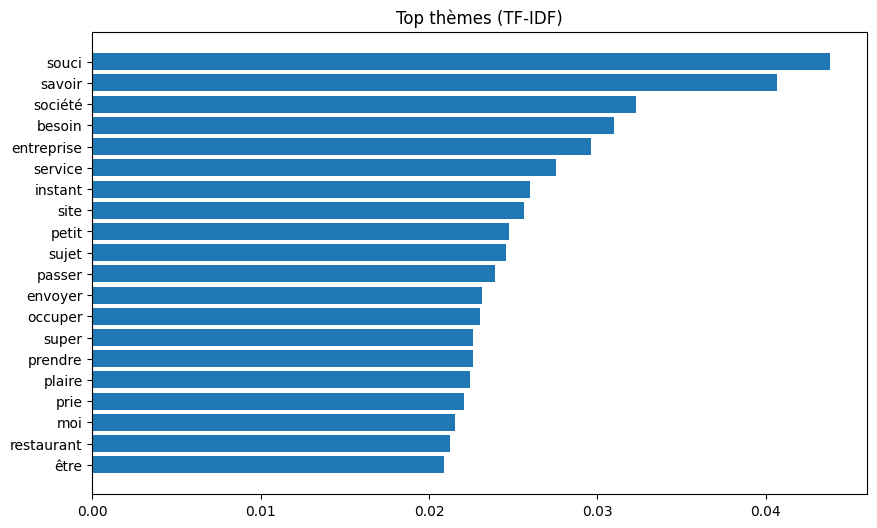

In [ ]:
top = df_themes.head(20)
plt.figure(figsize=(10,6))
plt.barh(top["term"][::-1], top["score"][::-1])
plt.title("Top thèmes (TF-IDF)")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

texts = df["prospect_clean"].fillna("").tolist()

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=3
)

X = tfidf.fit_transform(texts)

features = np.array(tfidf.get_feature_names_out())

print("TF-IDF matrix:", X.shape)

TF-IDF matrix: (310, 771)


In [ ]:
scores = np.asarray(X.mean(axis=0)).ravel()

top_idx = scores.argsort()[::-1][:50]

print("\nTOP TF-IDF GLOBAL:")
for i in top_idx:
    print(features[i], round(scores[i], 4))


TOP TF-IDF GLOBAL:
souci 0.0385
savoir 0.0338
société 0.0285
besoin 0.0267
entreprise 0.0249
service 0.0246
instant 0.023
site 0.0221
sujet 0.0219
petit 0.0218
envoyer 0.0211
occuper 0.0211
passer 0.021
prie 0.0199
prendre 0.0198
super 0.0197
plaire 0.0195
peut 0.0186
être 0.0186
peut être 0.0186
travailler 0.0185
moi 0.0183
contact 0.0182
vraiment 0.0177
restaurant 0.0177
temps 0.0176
midi 0.017
rien 0.0169
désoler 0.0165
restauration 0.0165
demain 0.0163
attendre 0.016
réunion 0.0157
regarder 0.0157
mettre 0.0156
vous 0.0155
aller 0.0154
nom 0.0154
essayer 0.0154
pardon 0.0152
chose 0.0151
travail 0.0147
moment 0.0146
désolé 0.0146
marche 0.0146
trop 0.0146
point 0.0145
quitter 0.0143
mal 0.0143
personne 0.014


In [ ]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=6, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_

def print_topics(H, features, top_n=10):
    for idx, topic in enumerate(H):
        print("\n====================")
        print("THEME", idx)
        words = [features[i] for i in topic.argsort()[-top_n:]]
        print(words)

print_topics(H, features)


THEME 0
['mettre', 'place', 'site', 'société', 'personne', 'plat', 'chose', 'restaurant', 'entreprise', 'savoir']

THEME 1
['quitter', 'disponibilité quitter', 'enregistrer', 'disponibilité', 'vérifier', 'motif vérifier', 'motif', 'enregistrer nom', 'nom motif', 'vérifier disponibilité']

THEME 2
['travail', 'contact', 'actualité', 'rien', 'savoir', 'passer', 'souci souci', 'besoin', 'occuper', 'souci']

THEME 3
['sujet', 'collègue', 'site', 'fait', 'actualité', 'travailler', 'besoin instant', 'instant besoin', 'besoin', 'instant']

THEME 4
['joindre', 'taper', 'prie', 'demander', 'envoyer', 'plaire', 'rendez', 'rendez vous', 'vous', 'service']

THEME 5
['matin', 'début', 'début après', 'demain', 'peut être', 'peut', 'être', 'après midi', 'après', 'midi']


In [ ]:
df["theme"] = W.argmax(axis=1)

print(df["theme"].value_counts())

theme
0    119
4     81
2     43
5     27
3     23
1     17
Name: count, dtype: int64


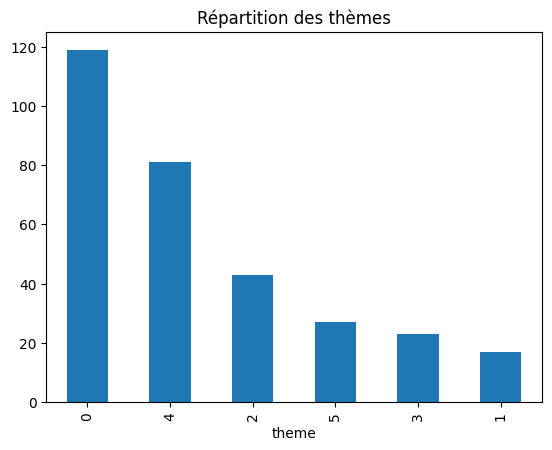

In [ ]:
import matplotlib.pyplot as plt

df["theme"].value_counts().plot(kind="bar")
plt.title("Répartition des thèmes")
plt.show()

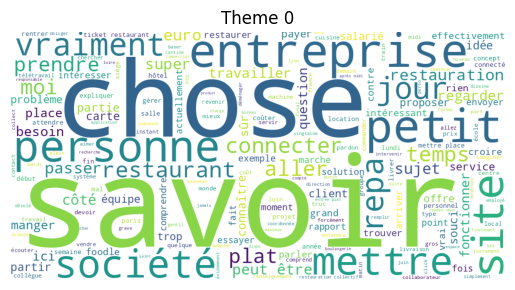

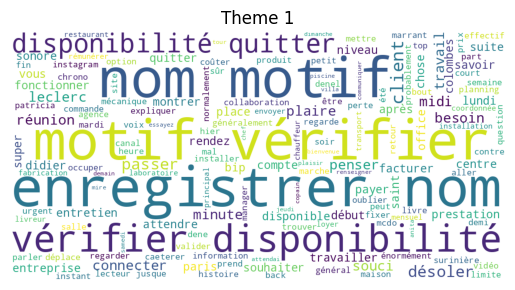

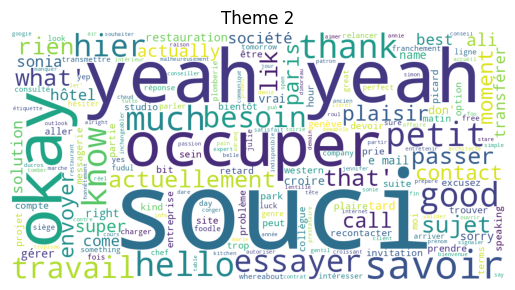

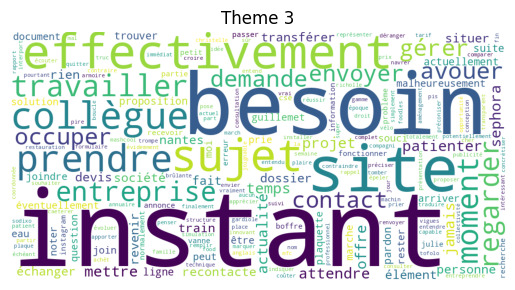

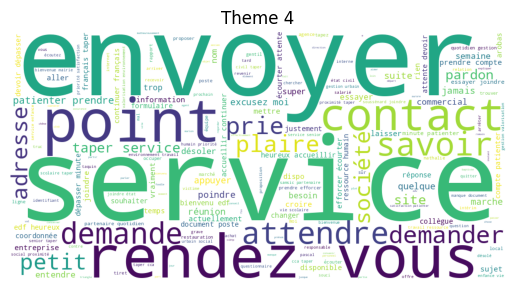

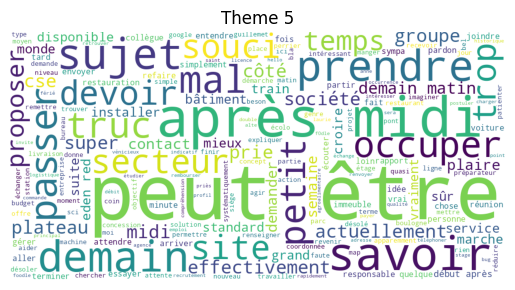

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for t in sorted(df["theme"].unique()):
    text = " ".join(df[df["theme"] == t]["prospect_clean"])

    wc = WordCloud(width=1000, height=500, background_color="white").generate(text)

    plt.figure()
    plt.title(f"Theme {t}")
    plt.imshow(wc)
    plt.axis("off")
    plt.show()

In [ ]:
import pandas as pd
import re

def kwic_raw(texts, target="savoir", window=10, n=50):

    rows = []

    pattern = re.compile(rf"\b{re.escape(target)}\b", re.IGNORECASE)

    for text in texts:
        if not isinstance(text, str):
            continue

        tokens = text.split()

        for i, w in enumerate(tokens):

            if pattern.fullmatch(w):

                left = tokens[max(0, i-window):i]
                right = tokens[i+1:i+window+1]

                rows.append({
                    "left": " ".join(left),
                    "target": w,
                    "right": " ".join(right)
                })

                if len(rows) >= n:
                    return pd.DataFrame(rows)

    return pd.DataFrame(rows)

In [ ]:
table = kwic_raw(df["prospect_clean"], target="savoir", window=10, n=100)
display(table.head())

,left,target,right
0,,savoir,site internet trompe laisser messager trompe r...
1,préparateur préparateur commande site vénicieu...,savoir,peut-être échange proposer peut-être profil in...
2,diallo ibrahima plaire service recrutemer plai...,savoir,recruter pousser pousser laurent
3,andered compte foodle payer connecté problème ...,savoir,problématique renseignement temps problème foo...
4,apparemment signaler mois actualité savoir pro...,savoir,arriver enregistrer carte ndr compte foodle mo...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),   # IMPORTANT : bigrammes
    min_df=5
)

X = vectorizer.fit_transform(df["prospect_clean"])

terms = vectorizer.get_feature_names_out()
scores = X.mean(axis=0).A1

tfidf_df = pd.DataFrame({
    "term": terms,
    "score": scores
}).sort_values("score", ascending=False)

tfidf_df.head(30)

,term,score
343,souci,0.044660
341,société,0.032644
29,besoin,0.031239
113,entreprise,0.029815
333,service,0.027392
337,site,0.026456
168,instant,0.026145
257,petit,0.024921
348,sujet,0.024849
247,passer,0.024327


In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.1 MB/s eta 0:00:00


In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# 1. EMBEDDINGS MULTILINGUE (IMPORTANT)
embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# 2. MODEL BERTopic
topic_model = BERTopic(
    embedding_model=embedding_model,
    language="french",
    min_topic_size=10,
    calculate_probabilities=True,
    verbose=True
)

# 3. TEXT INPUT (IMPORTANT: mieux vaut prospect_text que clean)
texts = df["prospect_text"].fillna("").tolist()

# 4. FIT
topics, probs = topic_model.fit_transform(texts)

df["topic"] = topics

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-06-02 18:06:37,413 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

2026-06-02 18:07:14,076 - BERTopic - Embedding - Completed ✓
2026-06-02 18:07:14,077 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-02 18:07:18,451 - BERTopic - Dimensionality - Completed ✓
2026-06-02 18:07:18,453 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-02 18:07:18,505 - BERTopic - Cluster - Completed ✓
2026-06-02 18:07:18,512 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-02 18:07:18,603 - BERTopic - Representation - Completed ✓


In [ ]:
topic_info = topic_model.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,35,-1_je_est_de_en,"[je, est, de, en, que, le, pas, et, vous, des]",[Bonjour. C'est moi-même. C'est ça. Non non no...
1,0,192,0_je_de_est_vous,"[je, de, est, vous, pas, oui, en, que, on, et]","[Allô. Oui, l'adresse c t, pardonnez-moi. Oui,..."
2,1,81,1_est_de_on_je,"[est, de, on, je, oui, pas, ça, vous, et, en]","[Oui bonjour. Non, c'est moi, je n'ai pas décr..."


In [ ]:
for topic_id in topic_info["Topic"].head(10):
    print("\n====================")
    print("TOPIC", topic_id)
    print(topic_model.get_topic(topic_id))


TOPIC -1
[('je', np.float64(0.07742579274715741)), ('est', np.float64(0.07638051978031907)), ('de', np.float64(0.07546538333739565)), ('en', np.float64(0.059930699764446115)), ('que', np.float64(0.058374296810701935)), ('le', np.float64(0.055168678030688464)), ('pas', np.float64(0.05417925086379948)), ('et', np.float64(0.052948507527255585)), ('vous', np.float64(0.04990140687862558)), ('des', np.float64(0.04860804697924024))]

TOPIC 0
[('je', np.float64(0.08277682205573061)), ('de', np.float64(0.07742956701386142)), ('est', np.float64(0.07636415704481583)), ('vous', np.float64(0.07601558090696522)), ('pas', np.float64(0.06612616991078132)), ('oui', np.float64(0.05829744024028364)), ('en', np.float64(0.050787832845215396)), ('que', np.float64(0.050331182175572704)), ('on', np.float64(0.04980097608406675)), ('et', np.float64(0.046554109174665806))]

TOPIC 1
[('est', np.float64(0.0975346722094611)), ('de', np.float64(0.07837233926380698)), ('on', np.float64(0.06761628938474595)), ('je', 

Embedding en cours...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Shape embeddings: (308, 384)
Clustering HDBSCAN...

Distribution clusters:
cluster
-1    247
 0     49
 1     12
Name: count, dtype: int64

PCA visualisation...


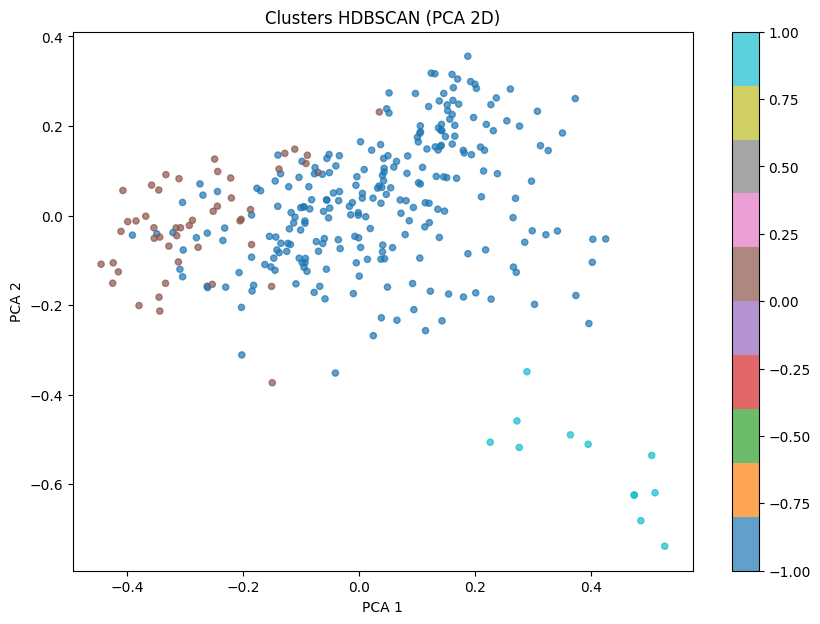


Wordclouds...


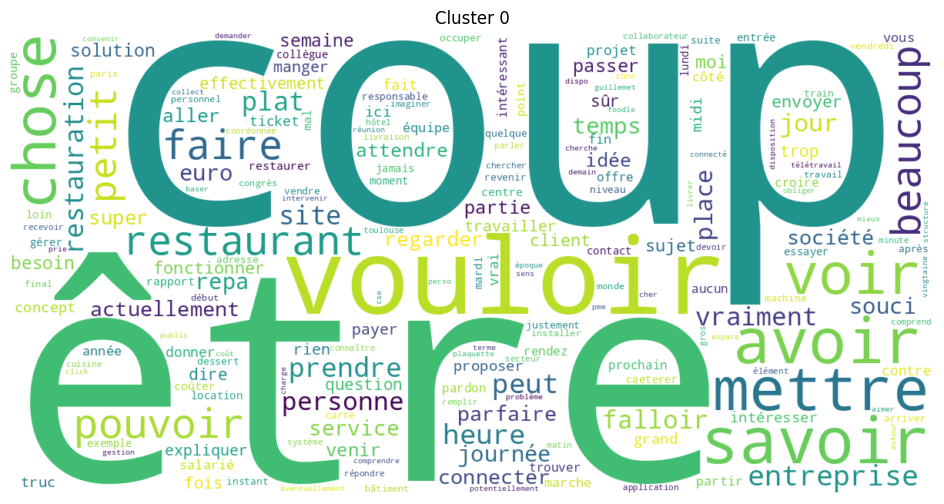

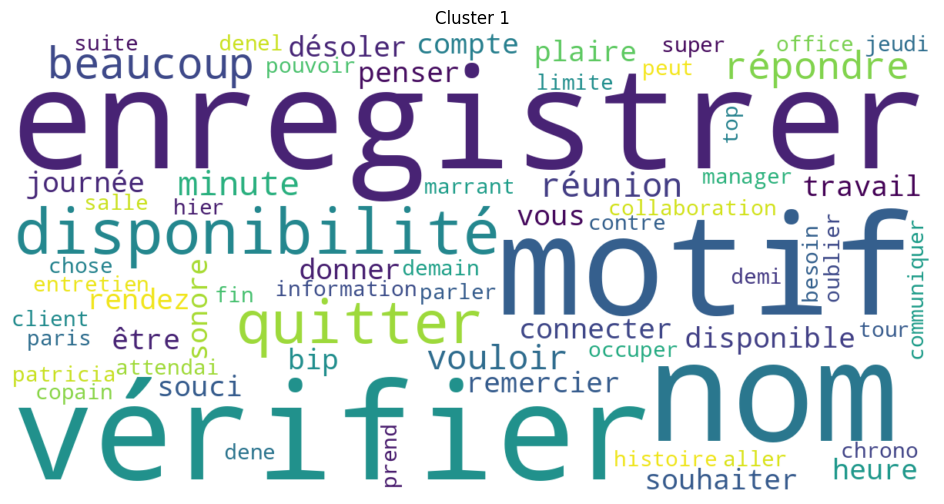


EXEMPLES PAR CLUSTER

CLUSTER -1
- avoir heure savoir heure site internet trompe laisser messager trompe rapport stage prendre stagiaire mois semaine stage rémunérer service commercial site site
- laurie anne charger recrutement agence alte emploi saint-priès permettre rapidement chercher préparateur préparateur commande site vénicieux vrai secteur principal travailler beaucoup logistique voulo
- nom diallo ibrahima plaire service recrutemer plaire recrutement annonce agent transit vouloir savoir recruter falloir pousser pousser remercier laurent
- petit renseignement concept restaurant mètre carré surface falloir falloir faut pouvoir envoyer technicien commercial expliquer
- excusez moi michel tir hôtel théoul hier petit malin consommer plat jour barquette barre chocolat figurer vous barre chocolat étiquette collée beaucoup journée michel tir hôtel employer prendre consom

CLUSTER 0
- prix restaurant nouveau concept local mètre carré ancien restaurant transformer concept vouloir serv

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import hdbscan
from wordcloud import WordCloud

# ============================================================
# 1. EMBEDDINGS
# ============================================================

print("Embedding en cours...")

model = SentenceTransformer("all-MiniLM-L6-v2")

texts = df["prospect_clean"].fillna("").tolist()

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Shape embeddings:", embeddings.shape)

# ============================================================
# 2. HDBSCAN CLUSTERING
# ============================================================

print("Clustering HDBSCAN...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean"
)

df["cluster"] = clusterer.fit_predict(embeddings)

print("\nDistribution clusters:")
print(df["cluster"].value_counts().sort_index())

# ============================================================
# 3. PCA VISUALISATION 2D
# ============================================================

print("\nPCA visualisation...")

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]

plt.figure(figsize=(10, 7))

plt.scatter(
    df["x"],
    df["y"],
    c=df["cluster"],
    cmap="tab10",
    s=20,
    alpha=0.7
)

plt.title("Clusters HDBSCAN (PCA 2D)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar()
plt.show()

# ============================================================
# 4. WORDCLOUD PAR CLUSTER
# ============================================================

print("\nWordclouds...")

clusters = sorted(df["cluster"].unique())

for c in clusters:

    if c == -1:
        continue  # bruit HDBSCAN

    cluster_text = " ".join(
        df[df["cluster"] == c]["prospect_clean"].astype(str)
    )

    if len(cluster_text.strip()) == 0:
        continue

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        collocations=False
    ).generate(cluster_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Cluster {c}")
    plt.show()

# ============================================================
# 5. EXEMPLES PAR CLUSTER (IMPORTANT POUR INTERPRÉTER)
# ============================================================

print("\nEXEMPLES PAR CLUSTER")

for c in sorted(df["cluster"].unique()):

    print("\n====================")
    print("CLUSTER", c)

    sample = df[df["cluster"] == c]["prospect_clean"].head(5).values

    for s in sample:
        print("-", s[:200])

In [ ]:
print(df1.shape)
print(df.shape)
print(df_all.shape)

(469, 18)
(72, 22)
(541, 22)


In [ ]:
print(df_all["Call ID"].nunique())
print(len(df_all))

539
541


In [ ]:
print(gsheet1.title)
print(gsheet2.title)

1. SDR ENTRANT WEB - filter
1. SDR MOBILE - filter


In [ ]:
df_all[df_all["Call Transcription"].str.len() == 0]

,Timestamp,DATE,WEEK,MONTH,YEAR,Call Direction,Call Type,Call Status,Aircall Tag,Durée,...,Foodles User Email,Lead Phone,Call ID,Call Recording,Call Transcription,Canal d'acquisition,Thème abordé,Objections,Intention d'achat,prospect_text
6,1777990730,05/05/2026 16:18:50,19,5,2026,inbound,voicemail,,,70,...,,33 2 98 94 98 32,3742936240,,,Hors scope,Hors scope,Hors scope,Hors scope,
9,1778059574,06/05/2026 11:26:14,19,5,2026,inbound,voicemail,,,64,...,,33 2 85 67 05 56,3745843931,recording,,Canal : Unknown,Hors scope,Hors scope,Hors scope,
12,1778070252,06/05/2026 14:24:12,19,5,2026,inbound,,no_available_agent,,25s,...,,33 2 85 67 05 56,3746576304,recording,,Hors scope,Hors scope,Hors scope,Hors scope,
34,1779261211,20/05/2026 09:13:31,21,5,2026,inbound,voicemail,no_available_agent,,21s,...,,33 5 49 36 64 24,3786930658,recording,,Hors scope,Hors scope,Hors scope,Hors scope,
44,1779550581,23/05/2026 17:36:21,21,5,2026,inbound,voicemail,abandoned_in_classic,,1m24s,...,,33 6 13 20 07 27,3798941572,recording,,Canal : Site Web,Hors scope,Hors scope,Hors scope,
66,1779995167,28/05/2026 21:06:07,22,5,2026,inbound,voicemail,out_of_opening_hours,,38s,...,,33 6 58 19 78 02,3814086923,recording,,,Hors scope,Hors scope,Hors scope,
67,1780051239,29/05/2026 12:40:39,22,5,2026,inbound,voicemail,agents_did_not_answer,,1m11s,...,,33 6 63 65 88 87,3816045916,recording,,,Hors scope,Hors scope,Hors scope,
114,1777993637,05/05/2026 17:07:17,19,5,2026,inbound,voicemail,,,14,...,,33 6 52 00 18 58,3743242259,,,NaN,NaN,NaN,NaN,
116,1777996042,05/05/2026 17:47:22,19,5,2026,inbound,voicemail,,,162,...,,33 6 58 93 94 30,3743457706,,,NaN,NaN,NaN,NaN,
137,1778075124,06/05/2026 15:45:24,19,5,2026,inbound,,agents_did_not_answer,,45s,...,,33 7 49 91 57 63,3746987030,recording,,NaN,NaN,NaN,NaN,


In [ ]:
display(df_all["prospect_text"].head())

,prospect_text
0,
1,
2,
3,
4,


In [ ]:
df_all["cluster"].value_counts()

,count
cluster,
0,166
4,153
3,68
1,59
2,32


In [ ]:
for i in range(k):
    print("\nCLUSTER", i)
    print(df_all[df_all["cluster"] == i]["prospect_text"].head(5))


CLUSTER 0
1     foodle user prospect foodle user prospect élis...
2     foodle user prospect Monsieur laurie ann charg...
4     foodle user lionel foodel prospect Monsieur dé...
8     prospect foodle user prospect nom diallo ibrah...
10    foodle user prospect foodle user prospect peti...
Name: prospect_text, dtype: object

CLUSTER 1
156    prospect avoir composer numéro accueil siège s...
165    prospect bienvenu sector vouloir patienter don...
168    prospect accueil chanteloup vouloir rester lig...
171    prospect bienvenu caisse cibtp centre vouloir ...
172    prospect bienvenu caisse cibtp centre vouloir ...
Name: prospect_text, dtype: object

CLUSTER 2
52     prospect être transférer messagerie tenter joi...
54     prospect foodle user prospect enregistrer nom ...
78     prospect foodle user prospect essayer joindre ...
85     prospect tour enregistrer nom motif vérifier d...
106    prospect être messagerie vouloir message signa...
Name: prospect_text, dtype: object

CLUSTER 3
6

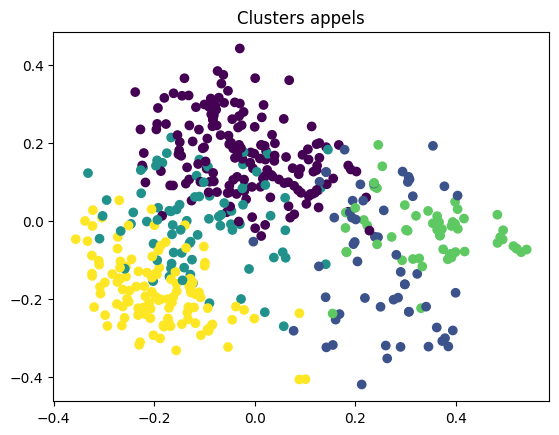

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.scatter(coords[:,0], coords[:,1], c=df_all["cluster"])
plt.title("Clusters appels")
plt.show()